In [1]:
#run the following for the first time
# try:
#     %pip install --user "oracledb" --no-warn-script-location
# except Exception as e:
#     print("\x1b[31m\u2717 Unexpected error! Please contact course staff\n" +
#          "Please include the entire text above and below in your message.")
#     raise

In [2]:
import oracledb
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dsn = oracledb.makedsn("localhost", 1522, service_name="stu")
connection = oracledb.connect(user="ora_lukeni", password="a54131032", dsn=dsn)

In [4]:
cur = connection.cursor()

In [5]:

# Define the grouped SQL query

query_line = """
SELECT year_quarter, SUM(COUNT) AS COUNT
FROM (
    SELECT year_quarter, SUM(total_bene_telehealth) AS COUNT
    FROM BENEFICIARY
    WHERE year_quarter NOT IN ('2020-Overall', '2021-Overall', '2022-Overall', '2023-Overall')
    GROUP BY year_quarter

    UNION ALL

    SELECT year_quarter, SUM(service_count) AS COUNT
    FROM SERVICECOUNT
    WHERE service_type != 'Store and forward'
    GROUP BY year_quarter

    UNION ALL
    SELECT year_quarter, COUNT(*) AS COUNT
    FROM PATIENTS
    GROUP BY year_quarter
)
GROUP BY year_quarter
ORDER BY year_quarter

"""


# Execute and fetch results into pandas DataFrame
cur.execute(query_line)
rows = cur.fetchall()

# Extract column names
columns = [desc[0] for desc in cur.description]

# Load into pandas DataFrame
line = pd.DataFrame(rows, columns=columns)

# Display the result
print(line)


   YEAR_QUARTER        COUNT
0        2018-1     539453.0
1        2018-2     581662.0
2        2018-3     650173.0
3        2018-4     730911.0
4        2019-1     849254.0
5        2019-2     896298.0
6        2019-3     934079.0
7        2019-4    1015466.0
8        2020-1   42673482.5
9        2020-2  269998027.5
10       2020-3  184078129.0
11       2020-4  182539105.5
12       2021-1  173561909.0
13       2021-2  124878053.0
14       2021-3  109592065.0
15       2021-4  106458687.0
16       2022-1  120600628.0
17       2022-2   98527157.5
18       2022-3   95720006.0
19       2022-4   94726537.0
20       2023-1   70334406.0
21       2023-2   62096082.0
22       2023-3   60349187.0
23       2023-4   63085068.5
24       2024-1   63933842.0
25       2024-2   59093042.0


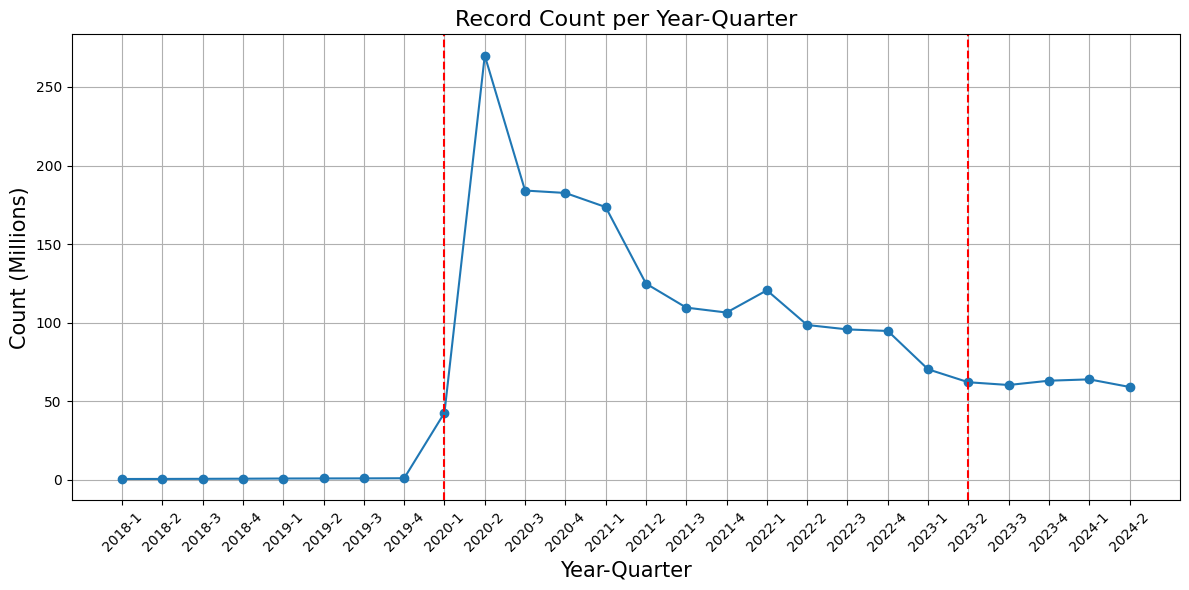

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(line['YEAR_QUARTER'], line['COUNT'] / 1e6, marker='o')

# Customize axis labels with increased font size
plt.title('Record Count per Year-Quarter', fontsize=16)
plt.xlabel('Year-Quarter', fontsize=15)
plt.ylabel('Count (Millions)', fontsize=15)

# Add red vertical dotted lines
plt.axvline(x='2020-1', color='red', linestyle='--', linewidth=1.5)
plt.axvline(x='2023-2', color='red', linestyle='--', linewidth=1.5)

# Improve x-axis readability
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Save plot to figures folder
plt.savefig('figures/line_chart.png', dpi=300)

# Show plot
plt.show()


In [7]:


query_avg = """
SELECT
  CASE
    WHEN year_quarter BETWEEN '2018-1' AND '2019-4' THEN 'Pre-Pandemic'
    WHEN year_quarter BETWEEN '2020-1' AND '2023-1' THEN 'During Pandemic'
    WHEN year_quarter >= '2023-2' THEN 'Post-Pandemic'
  END AS PERIOD,
  AVG(COUNT) AS AVG_COUNT
FROM (
  SELECT year_quarter, SUM(COUNT) AS COUNT
  FROM (
    SELECT year_quarter, SUM(total_bene_telehealth) AS COUNT
    FROM BENEFICIARY
    WHERE year_quarter NOT IN ('2020-Overall', '2021-Overall', '2022-Overall', '2023-Overall')
    GROUP BY year_quarter

    UNION ALL

    SELECT year_quarter, SUM(service_count) AS COUNT
    FROM SERVICECOUNT
    WHERE service_type != 'Store and forward'
    GROUP BY year_quarter

    UNION ALL

    SELECT year_quarter, COUNT(*) AS COUNT
    FROM PATIENTS
    GROUP BY year_quarter
  )
  GROUP BY year_quarter
)
GROUP BY
  CASE
    WHEN year_quarter BETWEEN '2018-1' AND '2019-4' THEN 'Pre-Pandemic'
    WHEN year_quarter BETWEEN '2020-1' AND '2023-1' THEN 'During Pandemic'
    WHEN year_quarter >= '2023-2' THEN 'Post-Pandemic'
  END
ORDER BY
  CASE
    WHEN PERIOD = 'Pre-Pandemic' THEN 1
    WHEN PERIOD = 'During Pandemic' THEN 2
    WHEN PERIOD = 'Post-Pandemic' THEN 3
  END

"""


# Execute and fetch results into pandas DataFrame
cur.execute(query_avg)
rows = cur.fetchall()

# Extract column names
columns = [desc[0] for desc in cur.description]

# Load into pandas DataFrame
temporal_df = pd.DataFrame(rows, columns=columns)

# Display the result
print(temporal_df)

            PERIOD     AVG_COUNT
0     Pre-Pandemic  7.746620e+05
1  During Pandemic  1.287452e+08
2    Post-Pandemic  6.171144e+07


In [8]:


sex = """
SELECT 
    sex,
    SUM(total_bene_th_elig) AS total_eligible,
    SUM(total_bene_telehealth) AS total_telehealth,
    ROUND(SUM(total_bene_telehealth) / SUM(total_bene_th_elig), 4) AS percent_telehealth
FROM 
    BENEFICIARY
GROUP BY 
    sex

"""


# Execute and fetch results into pandas DataFrame
cur.execute(sex)
rows = cur.fetchall()

# Extract column names
columns = [desc[0] for desc in cur.description]

# Load into pandas DataFrame
sex_df = pd.DataFrame(rows, columns=columns)


# Display the result
print(sex_df)

      SEX  TOTAL_ELIGIBLE  TOTAL_TELEHEALTH  PERCENT_TELEHEALTH
0    Male       906418546      1.830208e+08              0.2019
1  Female      1184824601      2.718834e+08              0.2295
2     All      9908752623      2.156156e+09              0.2176


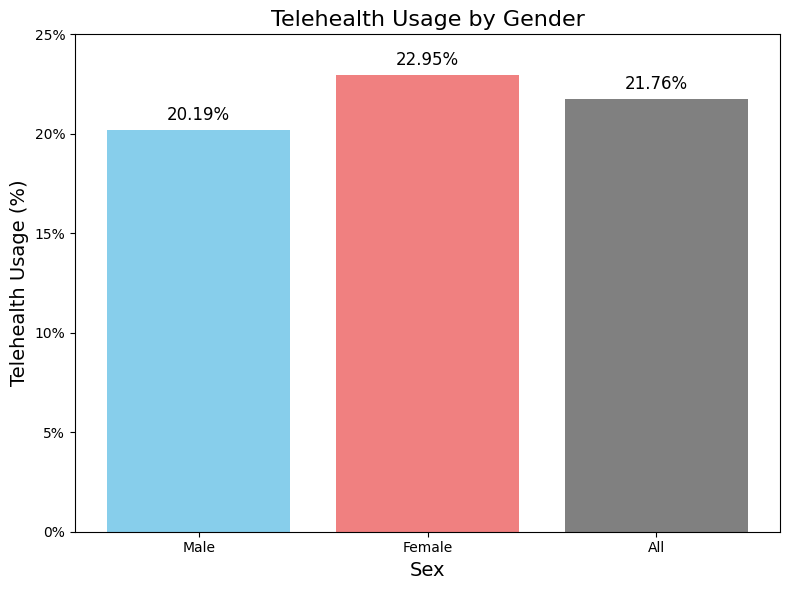

In [9]:


# Set figure size
plt.figure(figsize=(8, 6))

# Plot bar chart
plt.bar(sex_df['SEX'], sex_df['PERCENT_TELEHEALTH'], color=['skyblue', 'lightcoral', 'gray'])

# Add labels and title
plt.xlabel('Sex', fontsize=14)
plt.ylabel('Telehealth Usage (%)', fontsize=14)
plt.title('Telehealth Usage by Gender', fontsize=16)

# Convert proportion to percentage on y-axis
plt.gca().set_ylim(0, 0.25)
plt.gca().set_yticks([0.05 * i for i in range(6)])
plt.gca().set_yticklabels([f'{int(100 * i)}%' for i in plt.gca().get_yticks()])

# Show value labels on top of bars
for index, value in enumerate(sex_df['PERCENT_TELEHEALTH']):
    plt.text(index, value + 0.005, f'{value:.2%}', ha='center', fontsize=12)

# Save figure
plt.tight_layout()
plt.savefig('figures/bar_gender.png', dpi=300)

# Show the plot
plt.show()


In [10]:


age = """
SELECT 
    age_group AS AGE_GROUP,
    SUM(total_bene_th_elig) AS TOTAL_ELIGIBLE,
    SUM(total_bene_telehealth) AS TOTAL_TELEHEALTH,
    ROUND(SUM(total_bene_telehealth) / SUM(total_bene_th_elig), 4) AS PERCENT_TELEHEALTH
FROM BENEFICIARY
GROUP BY age_group
ORDER BY AGE_GROUP

"""


# Execute and fetch results into pandas DataFrame
cur.execute(age)
rows = cur.fetchall()

# Extract column names
columns = [desc[0] for desc in cur.description]

# Load into pandas DataFrame
age_df = pd.DataFrame(rows, columns=columns)

# Display the result
print(age_df)

     AGE_GROUP  TOTAL_ELIGIBLE  TOTAL_TELEHEALTH  PERCENT_TELEHEALTH
0         0-64       231708089      8.124888e+07              0.3507
1        65-74       940353010      1.925883e+08              0.2048
2        75-84       645145302      1.270445e+08              0.1969
3  85 and over       274036746      5.402245e+07              0.1971
4          All      9908752623      2.156156e+09              0.2176


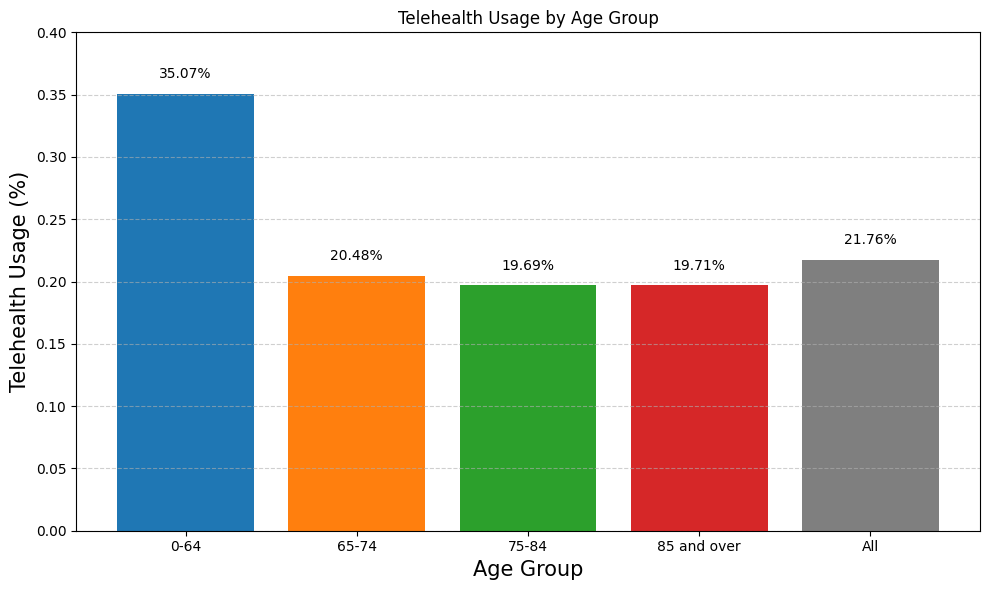

In [11]:


# Custom colors for each age group bar
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#7f7f7f']  # Blue, Orange, Green, Red, Gray

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(age_df['AGE_GROUP'], age_df['PERCENT_TELEHEALTH'], color=colors)

# Add percentage labels
for bar, value in zip(bars, age_df['PERCENT_TELEHEALTH']):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f"{value*100:.2f}%", 
             ha='center', va='bottom', fontsize=10)

# Chart styling
plt.ylim(0, 0.4)  # Extend Y-axis to show differences clearly
plt.ylabel('Telehealth Usage (%)', fontsize=15)
plt.xlabel('Age Group', fontsize=15)
plt.title('Telehealth Usage by Age Group')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save updated plot
plt.savefig('figures/bar_age_group.png', dpi=300)

# Show
plt.show()


In [12]:
# Define SQL query
state_time = """
SELECT 
    state_name,
    year_quarter,
    SUM(total_bene_th_elig) AS total_eligible,
    SUM(total_bene_telehealth) AS total_telehealth,
    ROUND(SUM(total_bene_telehealth) / SUM(total_bene_th_elig), 4) AS percent_telehealth
FROM 
    BENEFICIARY
WHERE 
    year_quarter NOT IN ('2020-Overall', '2021-Overall', '2022-Overall', '2023-Overall')
GROUP BY 
    state_name,
    year_quarter
ORDER BY 
    state_name, 
    year_quarter
"""

# Execute and load to DataFrame
cur.execute(state_time)
rows = cur.fetchall()
columns = [desc[0] for desc in cur.description]
state_quarter_df = pd.DataFrame(rows, columns=columns)

# View result
print(state_quarter_df.head())


  STATE_NAME YEAR_QUARTER  TOTAL_ELIGIBLE  TOTAL_TELEHEALTH  \
0    Alabama       2020-1         2749443          152287.0   
1    Alabama       2020-2         2550087          968439.0   
2    Alabama       2020-3         2693761          631877.0   
3    Alabama       2020-4         2660316          547079.0   
4    Alabama       2021-1         2488358          481808.0   

   PERCENT_TELEHEALTH  
0              0.0554  
1              0.3798  
2              0.2346  
3              0.2056  
4              0.1936  


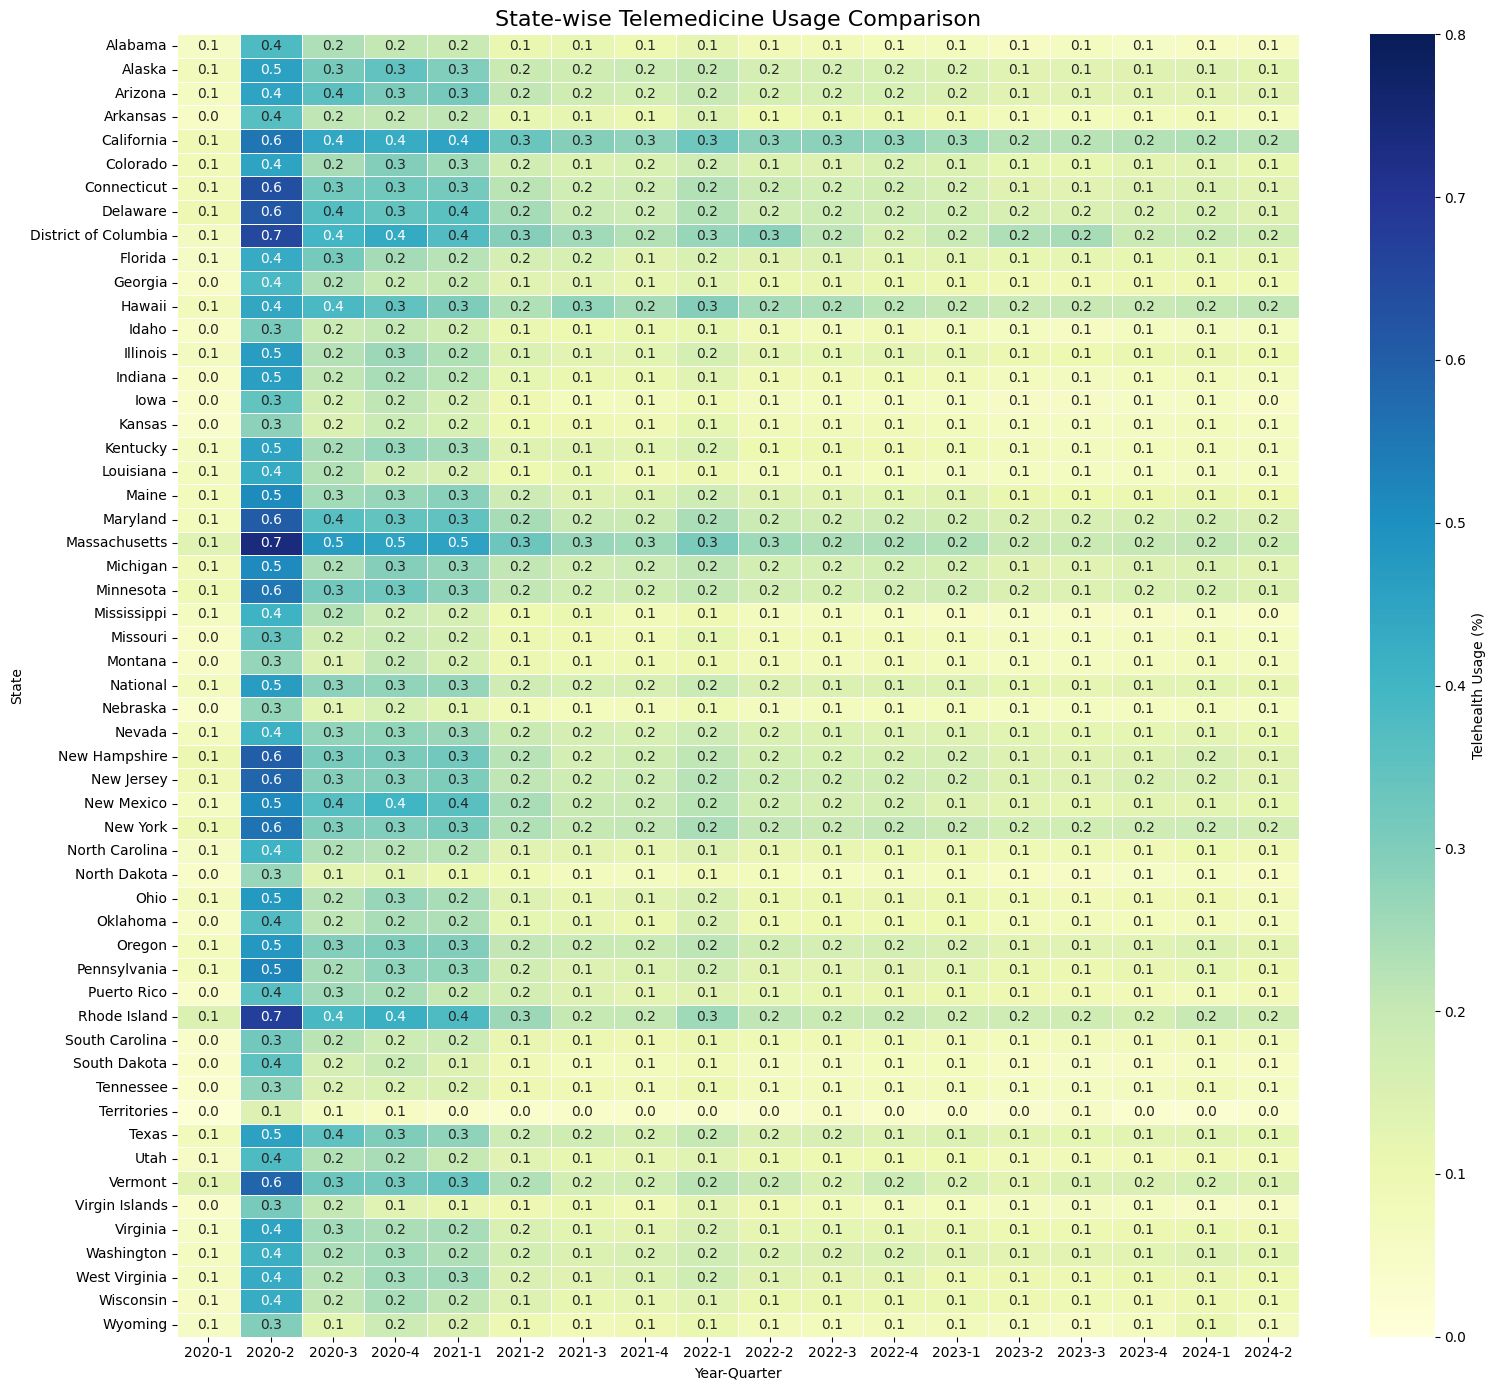

In [13]:


# Pivot the data to get a matrix of states vs year_quarters
heatmap_data = state_quarter_df.pivot(index='STATE_NAME', columns='YEAR_QUARTER', values='PERCENT_TELEHEALTH')

# Sort by state name (optional but neat)
heatmap_data = heatmap_data.sort_index()

# Set plot size
plt.figure(figsize=(16, 14))

# Create the heatmap
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cmap="YlGnBu",
    cbar_kws={'label': 'Telehealth Usage (%)'},
    vmin=0,
    vmax=0.8  # Set based on your range
)

# Title and labels
plt.title("State-wise Telemedicine Usage Comparison", fontsize=16)
plt.xlabel("Year-Quarter")
plt.ylabel("State")

# Save the figure
plt.tight_layout()
plt.savefig("figures/state_heatmap.png", dpi=300)

# Show the plot
plt.show()
